In [ ]:
import os
import requests
import time
import math
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from config import Config
from RNN import RNNModel, RNN
from dataset import CharDataset
from LSTM import LSTMTextGen

config = Config()

###Connect to GPU

In [100]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

drive_dir = "/content/drive/MyDrive/KP_MODEL"
os.makedirs(drive_dir, exist_ok=True)

checkpoint_path_rnn= os.path.join(drive_dir, "shakespeare_rnn.pth")
checkpoint_path_lstm=os.path.join(drive_dir, "shakespeare_lstm.pth")

In [ ]:
data_path = "/Users/laibaqureshi/Desktop/Text Generation/Text-Generation/shakespeare_2.txt"
rnn_trainer = RNN(data_path)

text = rnn_trainer.load()

In [ ]:
vocab_size, chars = rnn_trainer.build_vocab(text)

In [ ]:
char2idx = rnn_trainer.vectorise_text(chars)
idx2char = rnn_trainer.devectorise_text(char2idx)
encoded = rnn_trainer.encode_text(text, char2idx)

In [ ]:
# The maximum length sentence we want for a single input in characters.
batch_size = config.batch_size

examples_per_epoch = len(text) // (config.sequence_length + 1)

print('examples_per_epoch:', examples_per_epoch)

In [ ]:
split = int(config.train_split * len(encoded))

train_data = encoded[:split]
test_data  = encoded[split:]

dataset = CharDataset(train_data, config.sequence_length)
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

# LSTM

###LSTM Training Setup

In [123]:
# NEW LSTM MODEL + OPTIMIZER
lstm_model = LSTMTextGen(vocab_size).to(device)
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)
lstm_loss_fn = nn.CrossEntropyLoss()

# SEPARATE STORAGE LISTS
lstm_train_losses = []


###LSTM Early Stopping Training Loop

In [124]:
lstm_patience = 4
lstm_epochs = 100
skip_training = True


# RESUME CHECKPOINT IF EXISTS
# ------------------------------------------------------------
if os.path.exists(checkpoint_path_lstm):
    chkpt = torch.load(checkpoint_path_lstm, map_location=device)
    lstm_model.load_state_dict(chkpt["model_state"])
    lstm_optimizer.load_state_dict(chkpt["optimizer_state"])
    start_epoch = chkpt["epoch"] + 1
    best_lstm_train_loss = chkpt["best_train_loss"]
    lstm_wait = chkpt["wait"]
    lstm_train_losses = chkpt["train_losses"]
    if lstm_wait >= lstm_patience-1:
      print("Early stopping was already triggered previously at",start_epoch,". Not resuming training.")
      skip_training = True  # <--- STOP TRAINING
    else:
      print("Resuming training from epoch:", start_epoch)
else:
    start_epoch = 1
    best_lstm_train_loss = float('inf')
    lstm_wait = 0
    lstm_train_losses = []
    print("No checkpoint found. Starting fresh.")

if not skip_training:
  for epoch in range(start_epoch, lstm_epochs + 1):
      lstm_model.train()
      total_loss = 0
      steps = 0

      for x, y in data_loader:
          x, y = x.to(device), y.to(device)

          hidden = lstm_model.init_hidden(x.size(0))

          lstm_optimizer.zero_grad()
          logits, hidden = lstm_model(x, hidden)

          loss = lstm_loss_fn(logits.reshape(-1, vocab_size), y.reshape(-1))
          loss.backward()
          lstm_optimizer.step()

          total_loss += loss.item()
          steps += 1

      train_loss = total_loss / steps
      lstm_train_losses.append(train_loss)

      print(f"[LSTM] Epoch {epoch}/{lstm_epochs} | Train Loss: {train_loss:.4f}")

      # EARLY STOPPING BASED ON TRAINING LOSS
      if train_loss <= best_lstm_train_loss:
          best_lstm_train_loss = train_loss\

          # SAVE CHECKPOINT TO GOOGLE DRIVE
          torch.save({
              "epoch": epoch,
              "model_state": lstm_model.state_dict(),
              "optimizer_state": lstm_optimizer.state_dict(),
              "best_train_loss": best_lstm_train_loss,
              "wait": lstm_wait,
              "train_losses": lstm_train_losses
          }, checkpoint_path_lstm)

          print(" -> Saved checkpoint to Google Drive.")

      else:
          lstm_wait += 1
          print(f" -> No improvement. Patience {lstm_wait}/{lstm_patience}")
          if lstm_wait >= lstm_patience:
              print("Early stopping triggered!")
              break

Resuming training from epoch: 49


###PLOT LSTM TRAINING LOSS

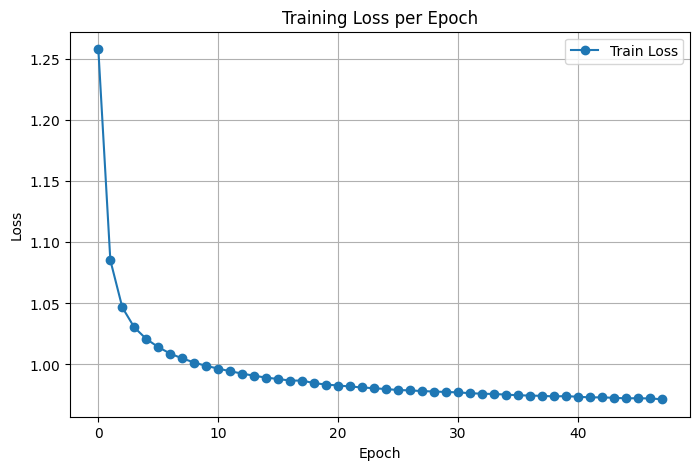

In [125]:
plt.figure(figsize=(8,5))
plt.plot(lstm_train_losses, marker='o', label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss per Epoch")
plt.grid(True)
plt.legend()
plt.show()

###Compare Training Loss

In [127]:
print("Final RNN Train Loss:", rnn_train_losses[-1])
print("Final LSTM Train Loss:", lstm_train_losses[-1])

Final RNN Train Loss: 1.2542213505984576
Final LSTM Train Loss: 0.9715301410196625
